## Stage 5: Preprocessing, KNN, and PCA
### Tasks
- Import librarires and preprocessing tools
- Load data
- Implement feature selection: numeric pipeline, categorical pipeline
- Preprocessing: Build SimpleImputer, StandardScaler, OneHotEncoder, **ColumnTransformer**
- Perform feature matrix
- Cosine similarity
- KNN model
- Query examples
- PCA
- Visualization

In [40]:
import pandas as pd
import os
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from dotenv import load_dotenv

load_dotenv(override=True)

Matplotlib is building the font cache; this may take a moment.


True

In [7]:
notebook_dir = os.getcwd() 
project_root = os.path.dirname(notebook_dir)  
output_dir = os.path.join(project_root, 'data', 'processed') 
os.makedirs(output_dir, exist_ok=True)

In [8]:
df = pd.read_csv(os.path.join(output_dir, 'icu_stay_features_stage3.csv'))

In [9]:
print(df.shape)

(94458, 42)


In [10]:
df.head()

,subject_id,hadm_id,stay_id,first_careunit,icu_los_days,gender,age,admission_type,race,hospital_expire_flag,...,heart_rate_max,resp_rate_max,sbp_max,spo2_max,temperature_max,heart_rate_std,resp_rate_std,sbp_std,spo2_std,temperature_std
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),0.410266,F,52,EW EMER.,WHITE,0,...,105.0,24.0,NaN,99.0,99.5,4.20,2.21,NaN,1.70,0.46
1,10000690,25860671,37081114,Medical Intensive Care Unit (MICU),3.893252,F,86,EW EMER.,WHITE,0,...,137.0,35.0,NaN,100.0,101.1,15.71,4.15,NaN,3.80,1.06
2,10000980,26913865,39765666,Medical Intensive Care Unit (MICU),0.497535,F,73,EW EMER.,BLACK/AFRICAN AMERICAN,0,...,80.0,25.0,NaN,100.0,98.7,3.59,3.80,NaN,1.58,0.51
3,10001217,24597018,37067082,Surgical Intensive Care Unit (SICU),1.118032,F,55,EW EMER.,WHITE,0,...,106.0,27.0,NaN,99.0,100.8,7.36,3.45,NaN,2.18,0.81
4,10001217,27703517,34592300,Surgical Intensive Care Unit (SICU),0.948113,F,55,DIRECT EMER.,WHITE,0,...,96.0,22.0,NaN,100.0,98.6,7.70,2.58,NaN,2.51,0.37


In [11]:
print(df.columns.tolist())

['subject_id', 'hadm_id', 'stay_id', 'first_careunit', 'icu_los_days', 'gender', 'age', 'admission_type', 'race', 'hospital_expire_flag', 'hypertension', 'hyperlipidemia', 'diabetes', 'heart_failure', 'coronary_artery_disease', 'atrial_fibrillation', 'chronic_kidney_disease', 'acute_kidney_injury', 'anemia', 'obesity', 'gerd', 'uti', 'heart_rate_mean', 'resp_rate_mean', 'sbp_mean', 'spo2_mean', 'temperature_mean', 'heart_rate_min', 'resp_rate_min', 'sbp_min', 'spo2_min', 'temperature_min', 'heart_rate_max', 'resp_rate_max', 'sbp_max', 'spo2_max', 'temperature_max', 'heart_rate_std', 'resp_rate_std', 'sbp_std', 'spo2_std', 'temperature_std']


In [12]:
categorical_features = [
    "gender",
    "race",
    "first_careunit",
    "admission_type",
]

In [13]:
diagnosis_features = [
    "hypertension",
    "hyperlipidemia",
    "diabetes",
    "heart_failure",
    "coronary_artery_disease",
    "atrial_fibrillation",
    "chronic_kidney_disease",
    "acute_kidney_injury",
    "anemia",
    "obesity",
    "gerd",
    "uti",
]

In [14]:
numeric_features = [
    "age",

    "heart_rate_mean",
    "resp_rate_mean",
    "sbp_mean",
    "spo2_mean",
    "temperature_mean",

    "heart_rate_min",
    "resp_rate_min",
    "sbp_min",
    "spo2_min",
    "temperature_min",

    "heart_rate_max",
    "resp_rate_max",
    "sbp_max",
    "spo2_max",
    "temperature_max",

    "heart_rate_std",
    "resp_rate_std",
    "sbp_std",
    "spo2_std",
    "temperature_std",
]

In [15]:
# Create a new DataFrame that contains only the modeling features
model_columns = (
    categorical_features +
    diagnosis_features +
    numeric_features
)

X = df[model_columns].copy()

print(X.shape)
X.head()

(94458, 37)


,gender,race,first_careunit,admission_type,hypertension,hyperlipidemia,diabetes,heart_failure,coronary_artery_disease,atrial_fibrillation,...,heart_rate_max,resp_rate_max,sbp_max,spo2_max,temperature_max,heart_rate_std,resp_rate_std,sbp_std,spo2_std,temperature_std
0,F,WHITE,Medical Intensive Care Unit (MICU),EW EMER.,0,0,0,0,0,0,...,105.0,24.0,NaN,99.0,99.5,4.20,2.21,NaN,1.70,0.46
1,F,WHITE,Medical Intensive Care Unit (MICU),EW EMER.,1,0,0,1,1,1,...,137.0,35.0,NaN,100.0,101.1,15.71,4.15,NaN,3.80,1.06
2,F,BLACK/AFRICAN AMERICAN,Medical Intensive Care Unit (MICU),EW EMER.,0,0,1,1,1,0,...,80.0,25.0,NaN,100.0,98.7,3.59,3.80,NaN,1.58,0.51
3,F,WHITE,Surgical Intensive Care Unit (SICU),EW EMER.,1,0,0,0,0,0,...,106.0,27.0,NaN,99.0,100.8,7.36,3.45,NaN,2.18,0.81
4,F,WHITE,Surgical Intensive Care Unit (SICU),DIRECT EMER.,1,0,0,0,0,0,...,96.0,22.0,NaN,100.0,98.6,7.70,2.58,NaN,2.51,0.37


In [16]:
# Fill missing values with the median and standardize the features
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

In [17]:
# Fill missing values with the most frequent value and One-hot encode them
categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [18]:
# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features + diagnosis_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [19]:
X_processed = preprocessor.fit_transform(X)
print(X_processed.shape)

(94458, 94)


## KNearest Neighbors (KNN)

In [21]:
knn = NearestNeighbors(
    n_neighbors=6,
    metric='cosine'
)
knn.fit(X_processed)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",6
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
effective_metric_ effective_metric_: strMetric used to compute distances to neighbors.,str,'cosine'
effective_metric_params_ effective_metric_params_: dictParameters for the metric used to compute distances to neighbors.,dict,{}


In [26]:
query_index = 0

In [28]:
# Find neighbors
distances, indices = knn.kneighbors(
    X_processed[query_index:query_index + 1],
    return_distance=True
)

In [32]:
# Display the results
results = pd.DataFrame({
    'Neighbor_index': indices[0],
    'Cosine_Distance': distances[0]
})
results

,Neighbor_index,Cosine_Distance
0,0,1.110223e-16
1,4027,1.131146e-01
2,7590,1.166916e-01
3,10086,1.197470e-01
4,22602,1.207858e-01
5,26002,1.226296e-01


In [30]:
# Retrieve actual patient record
df.iloc[indices[0]]

,subject_id,hadm_id,stay_id,first_careunit,icu_los_days,gender,age,admission_type,race,hospital_expire_flag,...,heart_rate_max,resp_rate_max,sbp_max,spo2_max,temperature_max,heart_rate_std,resp_rate_std,sbp_std,spo2_std,temperature_std
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),0.410266,F,52,EW EMER.,WHITE,0,...,105.0,24.0,NaN,99.0,99.5,4.20,2.21,NaN,1.70,0.46
4027,10439781,29717790,30397416,Surgical Intensive Care Unit (SICU),0.530255,F,65,EW EMER.,WHITE,0,...,98.0,27.0,NaN,99.0,99.3,6.68,3.20,NaN,1.51,0.41
7590,10822063,20975572,39502970,Coronary Care Unit (CCU),0.518877,F,48,EW EMER.,WHITE,0,...,128.0,28.0,NaN,99.0,99.3,6.26,3.36,NaN,1.28,0.29
10086,11083201,29008365,35345761,Medical Intensive Care Unit (MICU),0.880162,F,43,URGENT,WHITE,0,...,119.0,26.0,NaN,100.0,98.9,6.66,3.02,NaN,2.16,0.22
22602,12409915,27620242,32214186,Medical Intensive Care Unit (MICU),0.788600,F,47,EW EMER.,WHITE,0,...,119.0,31.0,NaN,100.0,98.6,6.06,3.29,NaN,2.09,0.13
26002,12758384,26921501,33617683,Medical/Surgical Intensive Care Unit (MICU/SICU),3.673657,M,48,EW EMER.,WHITE,1,...,103.0,21.0,NaN,97.0,99.0,2.83,0.71,NaN,0.71,0.07


In [ ]:
# Display the Cosine_Distance, Similarity, and Rank of the patients
diagnosis_cols = diagnosis_features

comparison = df.iloc[indices[0]][
    ["stay_id", "age", "gender"] + diagnosis_cols
].copy()

comparison["Cosine_Distance"] = distances[0]
comparison["Similarity"] = 1 - distances[0]
comparison["Rank"] = range(1, len(comparison) + 1)

comparison = comparison[
    ["Rank", "stay_id", "Similarity", "Cosine_Distance",
     "age", "gender"] + diagnosis_cols
]

comparison

,Rank,stay_id,Similarity,Cosine_Distance,age,gender,hypertension,hyperlipidemia,diabetes,heart_failure,coronary_artery_disease,atrial_fibrillation,chronic_kidney_disease,acute_kidney_injury,anemia,obesity,gerd,uti
0,1,39553978,1.000000,1.110223e-16,52,F,0,0,0,0,0,0,0,0,0,0,0,0
4027,2,30397416,0.886885,1.131146e-01,65,F,0,0,0,0,0,0,0,0,0,0,0,0
7590,3,39502970,0.883308,1.166916e-01,48,F,0,0,0,0,0,0,0,0,0,0,0,0
10086,4,35345761,0.880253,1.197470e-01,43,F,0,0,0,0,0,0,0,0,0,0,0,0
22602,5,32214186,0.879214,1.207858e-01,47,F,0,0,0,0,0,0,0,0,0,0,0,0
26002,6,33617683,0.877370,1.226296e-01,48,M,0,0,0,0,0,0,0,0,0,0,0,0


In [34]:
df[
    diagnosis_features
].sum().sort_values(ascending=False)

hypertension               44119
anemia                     42358
hyperlipidemia             36039
acute_kidney_injury        30250
atrial_fibrillation        27348
heart_failure              26276
coronary_artery_disease    25432
diabetes                   25244
chronic_kidney_disease     20424
gerd                       20161
uti                        12376
obesity                    10942
dtype: int64

In [35]:
# Query a patient with several chronic conditions
query_candidates = df[
    (df["hypertension"] == 1) &
    (df["diabetes"] == 1) &
    (df["heart_failure"] == 1)
]

print(query_candidates.shape)
query_candidates.head()

(3228, 42)


,subject_id,hadm_id,stay_id,first_careunit,icu_los_days,gender,age,admission_type,race,hospital_expire_flag,...,heart_rate_max,resp_rate_max,sbp_max,spo2_max,temperature_max,heart_rate_std,resp_rate_std,sbp_std,spo2_std,temperature_std
20,10002495,24982426,36753294,Coronary Care Unit (CCU),5.087512,M,81,URGENT,UNKNOWN,0,...,150.0,35.0,136.0,100.0,98.7,12.72,3.69,15.20,2.45,0.29
49,10005593,26835370,32896438,Cardiac Vascular Intensive Care Unit (CVICU),0.292847,M,61,OBSERVATION ADMIT,UNKNOWN,0,...,80.0,16.0,138.0,100.0,NaN,4.44,1.99,12.64,0.00,NaN
50,10005593,26835370,34389119,Cardiac Vascular Intensive Care Unit (CVICU),3.104306,M,61,OBSERVATION ADMIT,UNKNOWN,0,...,82.0,27.0,138.0,100.0,98.7,4.82,4.31,10.55,1.73,0.41
52,10005817,20626031,32604416,Cardiac Vascular Intensive Care Unit (CVICU),2.359097,M,66,URGENT,WHITE,0,...,100.0,25.0,172.0,100.0,98.6,9.38,4.07,17.52,2.43,0.17
60,10006508,26194826,32669861,Medical/Surgical Intensive Care Unit (MICU/SICU),2.048426,F,71,OBSERVATION ADMIT,BLACK/AFRICAN AMERICAN,0,...,102.0,31.0,NaN,100.0,99.8,9.62,3.58,NaN,3.00,0.54


In [37]:
query_index = query_candidates.index[0]
print(query_index)

20


In [38]:
distances, indices = knn.kneighbors(
    X_processed[query_index:query_index + 1],
    return_distance=True
)

In [ ]:
# Compare patients with similar chronic diseases
comparison = df.iloc[indices[0]][
    ["stay_id", "age", "gender", "first_careunit"] + diagnosis_features
].copy()

comparison["Cosine_Distance"] = distances[0]
comparison["Similarity"] = 1 - distances[0]
comparison["Rank"] = range(1, len(comparison) + 1)

comparison = comparison[
    ["Rank", "stay_id", "Similarity", "Cosine_Distance",
     "age", "gender", "first_careunit"] + diagnosis_features
]

comparison

,Rank,stay_id,Similarity,Cosine_Distance,age,gender,first_careunit,hypertension,hyperlipidemia,diabetes,heart_failure,coronary_artery_disease,atrial_fibrillation,chronic_kidney_disease,acute_kidney_injury,anemia,obesity,gerd,uti
20,1,36753294,1.000000,0.000000,81,M,Coronary Care Unit (CCU),1,1,1,1,1,1,0,1,0,0,1,0
34931,2,37475034,0.788986,0.211014,64,M,Coronary Care Unit (CCU),1,1,0,1,1,1,0,1,0,0,1,0
20763,3,39526077,0.777043,0.222957,91,F,Cardiac Vascular Intensive Care Unit (CVICU),0,1,1,1,1,1,0,1,0,0,1,0
20762,4,35228386,0.764918,0.235082,91,F,Coronary Care Unit (CCU),0,1,1,1,1,1,0,1,0,0,1,0
89398,5,38779705,0.740876,0.259124,88,M,Coronary Care Unit (CCU),1,1,0,1,1,1,0,1,0,0,1,0
12547,6,32099311,0.731788,0.268212,80,M,Medical Intensive Care Unit (MICU),1,1,1,1,1,1,0,1,1,0,1,0


## Interpretation of the above results

The retrieved neighbors share multiple cardiovascular comorbidities, including heart failure, coronary artery disease, atrial fibrillation, hyperlipidemia, and acute kidney injury. Although some demographic characteristics differ (e.g., age, gender, or ICU unit), the similarity model correctly emphasizes shared clinical conditions rather than exact demographic matches. This suggests that the engineered diagnosis features meaningfully contribute to patient retrieval.

## Principal Component Analysis (PCA)

In [51]:
# Principal Component Analysis
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_processed)
print(X_pca.shape)

(94458, 2)


In [52]:
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[0.12105224 0.0837868 ]
0.20483903297608014


In [ ]:
# Create reusable patient search function 
def find_similar_patients(
    stay_id,
    df,
    X_processed,
    knn,
    diagnosis_features,
    top_k=5,
):
    """
    Find the most similar ICU patients using KNN with cosine distance.
    """

    # Find row index for the requested stay
    match = df.index[df["stay_id"] == stay_id]

    if len(match) == 0:
        raise ValueError(f"stay_id {stay_id} not found.")

    query_index = match[0]

    distances, indices = knn.kneighbors(
        X_processed[query_index:query_index + 1],
        n_neighbors=top_k + 1,
        return_distance=True,
    )

    results = df.iloc[indices[0]].copy()

    results["Similarity"] = 1 - distances[0]
    results["Cosine_Distance"] = distances[0]
    results["Rank"] = range(1, len(results) + 1)

    display_columns = [
        "Rank",
        "stay_id",
        "Similarity",
        "Cosine_Distance",
        "age",
        "gender",
        "first_careunit",
    ] + diagnosis_features

    return results[display_columns]

In [55]:
# Find patient with similar features as stay_id=36753294
find_similar_patients(
    stay_id=36753294,
    df=df,
    X_processed=X_processed,
    knn=knn,
    diagnosis_features=diagnosis_features,
)

,Rank,stay_id,Similarity,Cosine_Distance,age,gender,first_careunit,hypertension,hyperlipidemia,diabetes,heart_failure,coronary_artery_disease,atrial_fibrillation,chronic_kidney_disease,acute_kidney_injury,anemia,obesity,gerd,uti
20,1,36753294,1.000000,0.000000,81,M,Coronary Care Unit (CCU),1,1,1,1,1,1,0,1,0,0,1,0
34931,2,37475034,0.788986,0.211014,64,M,Coronary Care Unit (CCU),1,1,0,1,1,1,0,1,0,0,1,0
20763,3,39526077,0.777043,0.222957,91,F,Cardiac Vascular Intensive Care Unit (CVICU),0,1,1,1,1,1,0,1,0,0,1,0
20762,4,35228386,0.764918,0.235082,91,F,Coronary Care Unit (CCU),0,1,1,1,1,1,0,1,0,0,1,0
89398,5,38779705,0.740876,0.259124,88,M,Coronary Care Unit (CCU),1,1,0,1,1,1,0,1,0,0,1,0
12547,6,32099311,0.731788,0.268212,80,M,Medical Intensive Care Unit (MICU),1,1,1,1,1,1,0,1,1,0,1,0


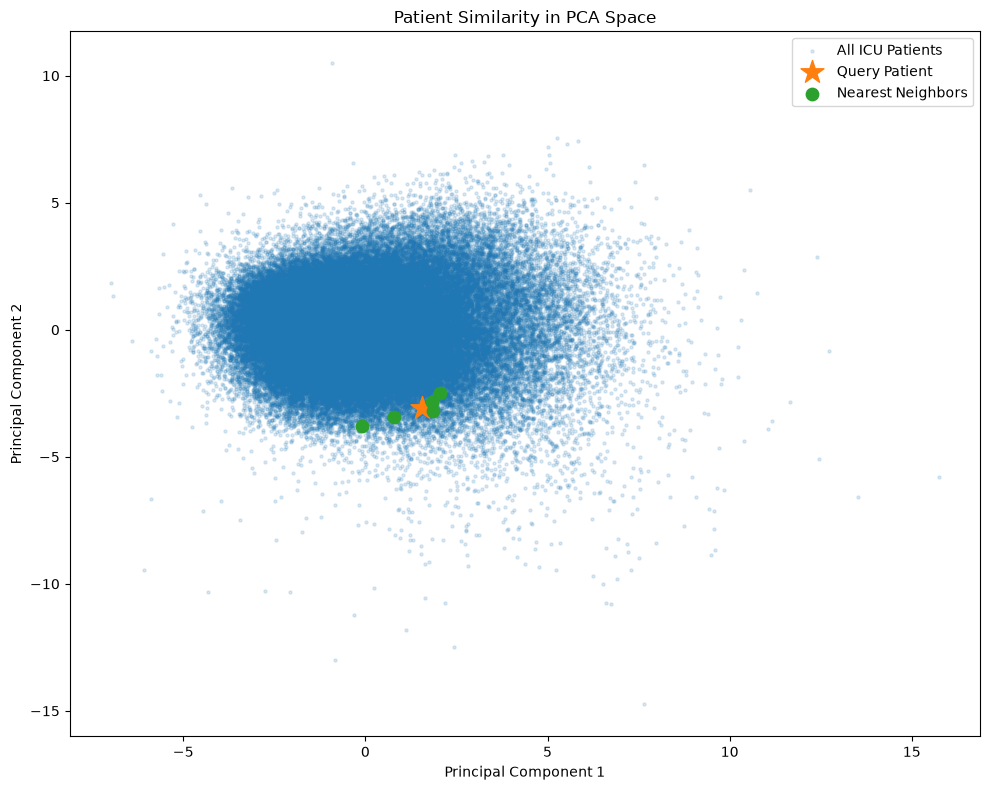

In [ ]:
# PCA plot
plt.figure(figsize=(10, 8))

# All ICU patients
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    s=5,
    alpha=0.15,
    label="All ICU Patients"
)

# Query patient
plt.scatter(
    X_pca[query_index, 0],
    X_pca[query_index, 1],
    marker="*",
    s=300,
    label="Query Patient"
)

# Neighbors (excluding the query itself)
neighbor_idx = indices[0][1:]

plt.scatter(
    X_pca[neighbor_idx, 0],
    X_pca[neighbor_idx, 1],
    s=80,
    label="Nearest Neighbors"
)

plt.title("Patient Similarity in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()

plt.tight_layout()

plt.savefig("../figures/patient_similarity_pca.png", dpi=300)

plt.show()

## Interpretation

Principal Component 1 explained 12.1% of the total variance, while Principal Component 2 explained 8.4%, for a combined 20.5%. Although the first two components capture only a portion of the original 94-dimensional feature space, they provide a useful low-dimensional visualization of patient relationships and allow the query patient and its nearest neighbors to be explored visually.